# Proyecto de Minería de Datos - Primer Avance
Este notebook incluye el análisis paso a paso usando el dataset `Cancer_Data.csv`.
Se realizará el Análisis Exploratorio de Datos (EDA), y luego se aplicarán modelos de Regresión Logística y Árboles de Decisión paso a paso.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Para asegurar que las gráficas se carguen correctamente:
%matplotlib inline
plt.style.use('ggplot')
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Carga y Exploración de Datos
Cargamos el dataset y revisamos sus dimensiones y primeras filas.

In [58]:
# Cargar el dataset
df = pd.read_csv('Cancer_Data.csv')

# Limpiar nombres de columnas (eliminar espacios y comillas)
df.columns = df.columns.str.replace('"', '').str.strip()

# Limpiar valores de texto en todo el dataframe (ej: " M " -> "M")
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

print("Dimensiones originales:", df.shape)

display(df.head())
display(df.info())

Dimensiones originales: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

None

### 1.1 Limpieza de Datos
Verificamos valores faltantes y eliminamos columnas irrelevantes.

In [59]:
import numpy as np
import pandas as pd # Ensure pandas is imported
import os

# Cargar el dataset para asegurar un estado fresco del DataFrame
file_path = 'Cancer_Data.csv'
if not os.path.exists(file_path):
    file_path = '/content/sample_data/Cancer_Data.csv'
df = pd.read_csv(file_path)

# Limpiar nombres de columnas (eliminar espacios y comillas) - moved from previous cell
df.columns = df.columns.str.replace('"', '').str.strip()

# Limpiar valores de texto en todo el dataframe (ej: " M " -> "M") - moved from previous cell
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# Cantidad de faltantes por columna
print("Faltantes por columna:")
display(df.isna().sum().sort_values(ascending=False).head(5))

# Eliminar columnas irrelevantes (id y la última columna vacía que suele aparecer)
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
# If there's an unnamed column, this might be it. Dropping based on `df.isna().all()` later is more robust.
if 'Unnamed: 32' in df.columns:
    df.drop('Unnamed: 32', axis=1, inplace=True)

# Identify columns with all NaNs, but exclude 'diagnosis' from this list
# 'diagnosis' is the target variable and should not be dropped, even if it appears to be all NaNs
cols_to_drop_nan = [col for col in df.columns if col != 'diagnosis' and df[col].isna().all()]

if cols_to_drop_nan:
    df.drop(columns=cols_to_drop_nan, inplace=True)
    print(f"Columnas con solo NaN eliminadas: {cols_to_drop_nan}")

# Codificar la variable objetivo (Maligno = 1, Benigno = 0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("Dimensiones limpias:", df.shape)

Faltantes por columna:


                569
id                0
diagnosis         0
texture_mean      0
radius_mean       0
dtype: int64

Columnas con solo NaN eliminadas: ['']
Dimensiones limpias: (569, 31)


### 1.2 Análisis Exploratorio de Datos (EDA)
Analizaremos la distribución de algunas variables importantes y su relación con el diagnóstico.

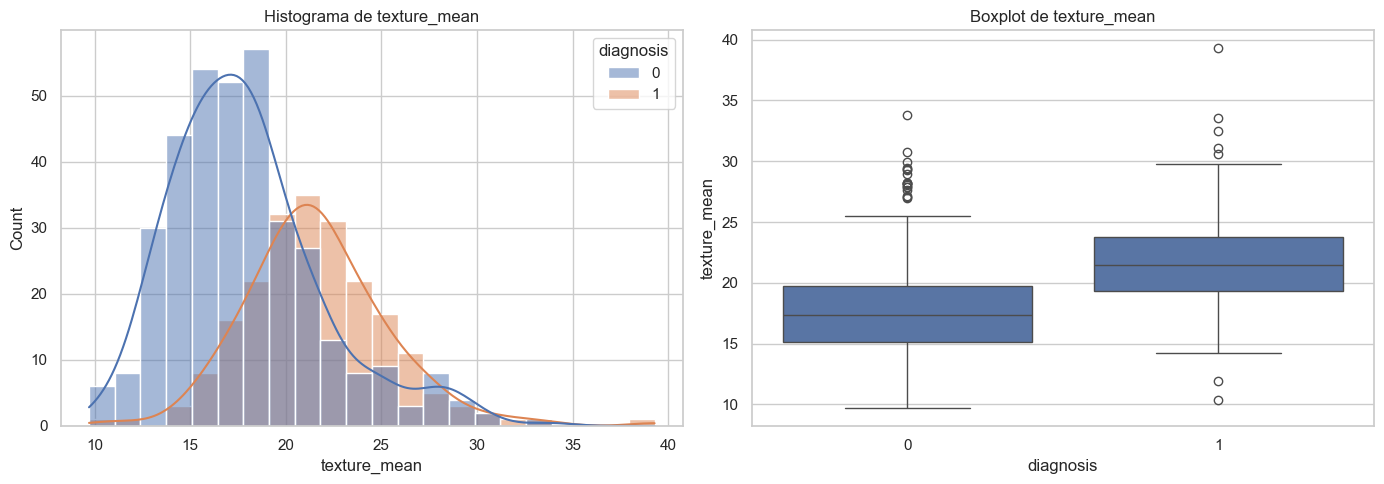

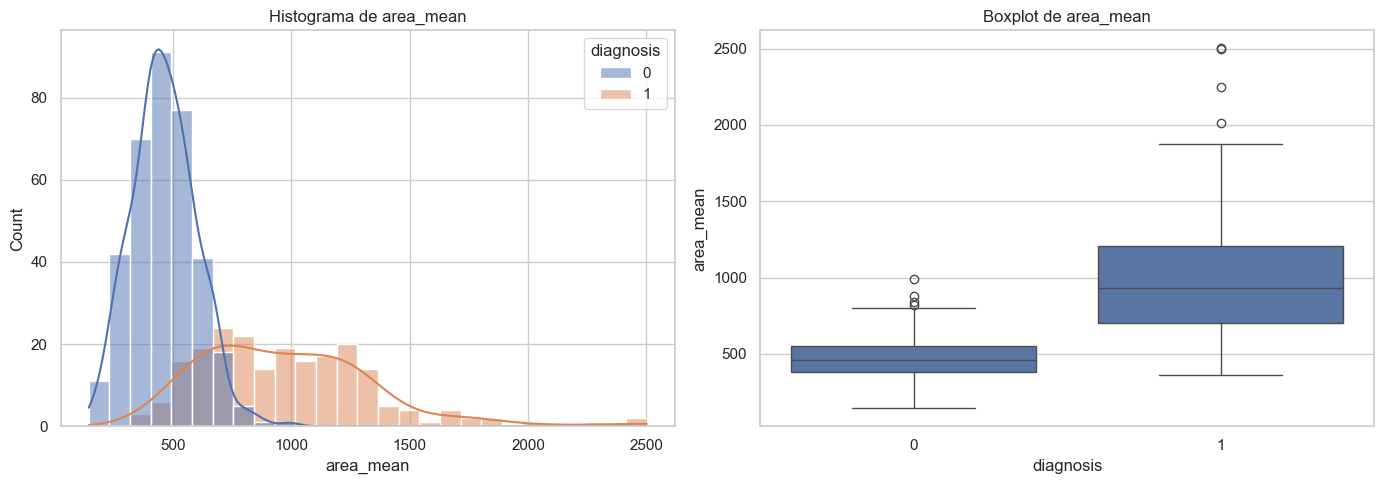

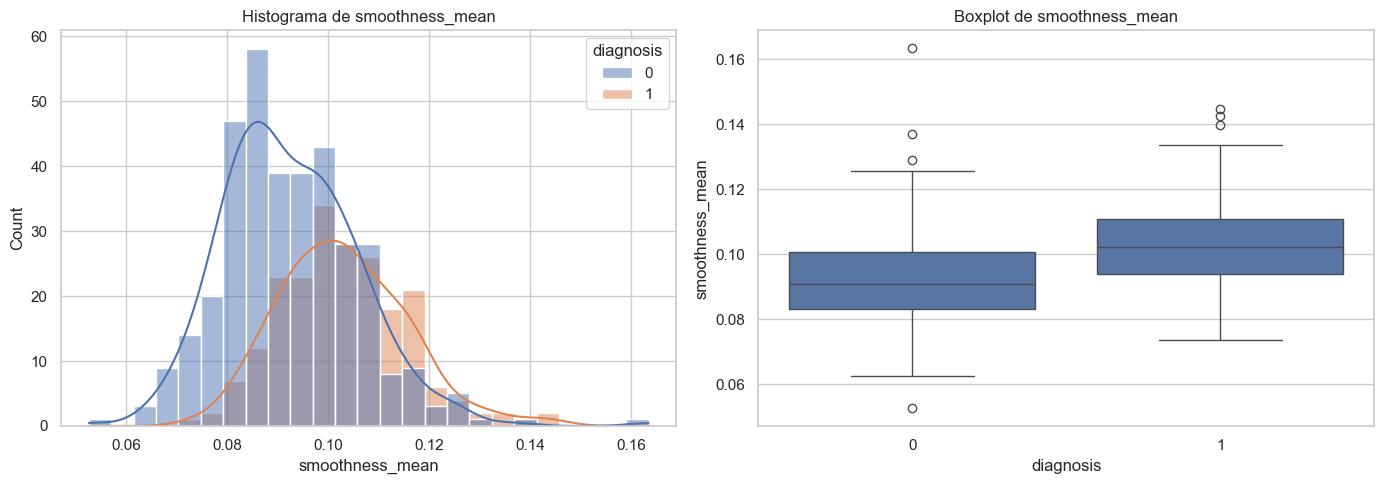

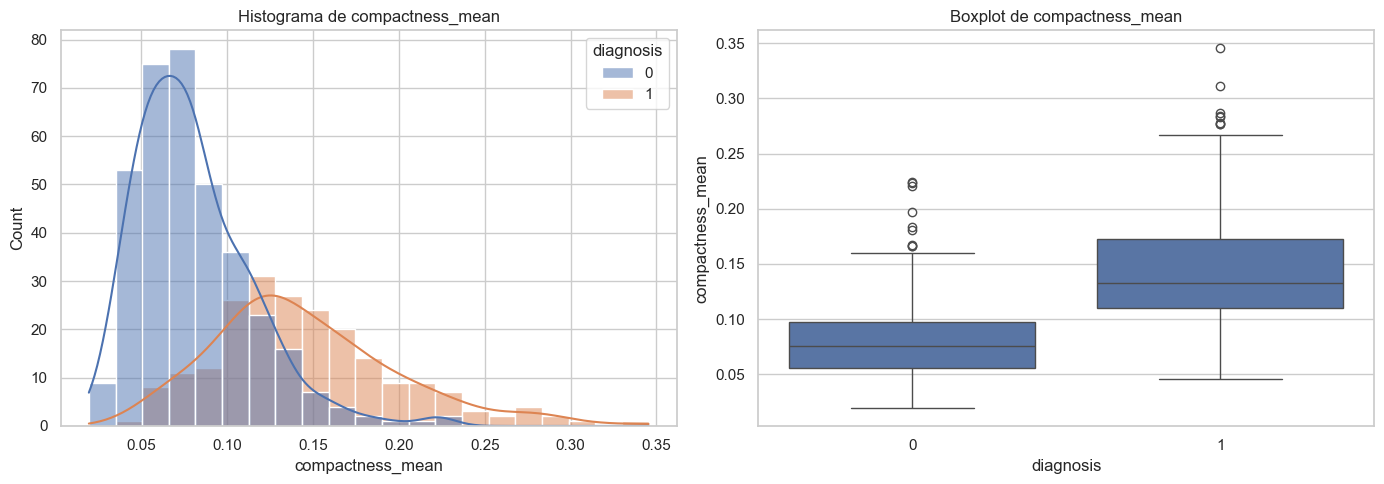

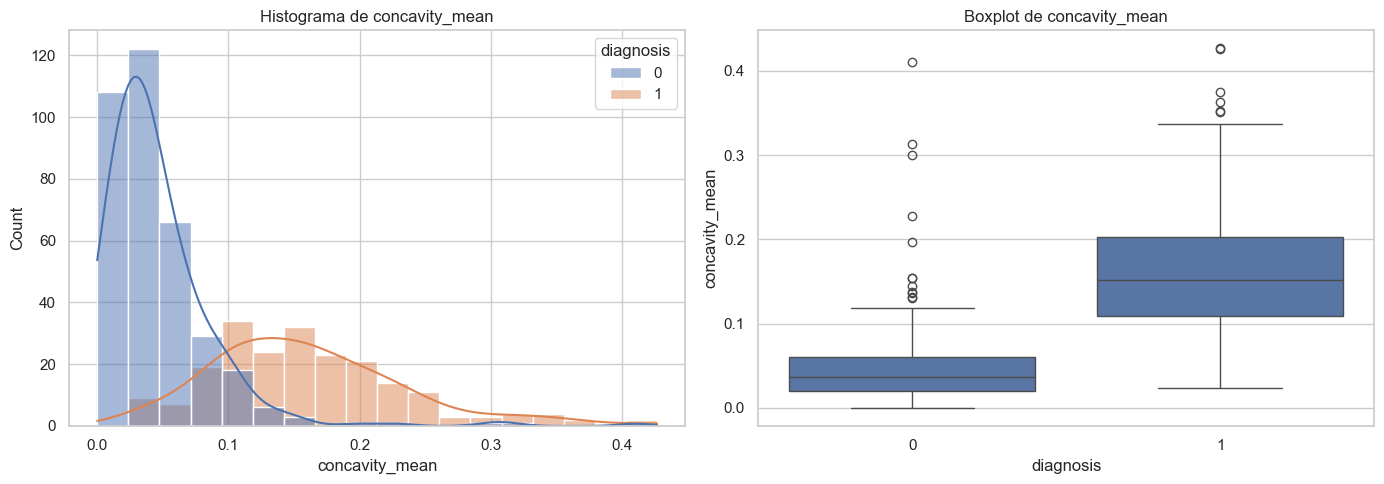

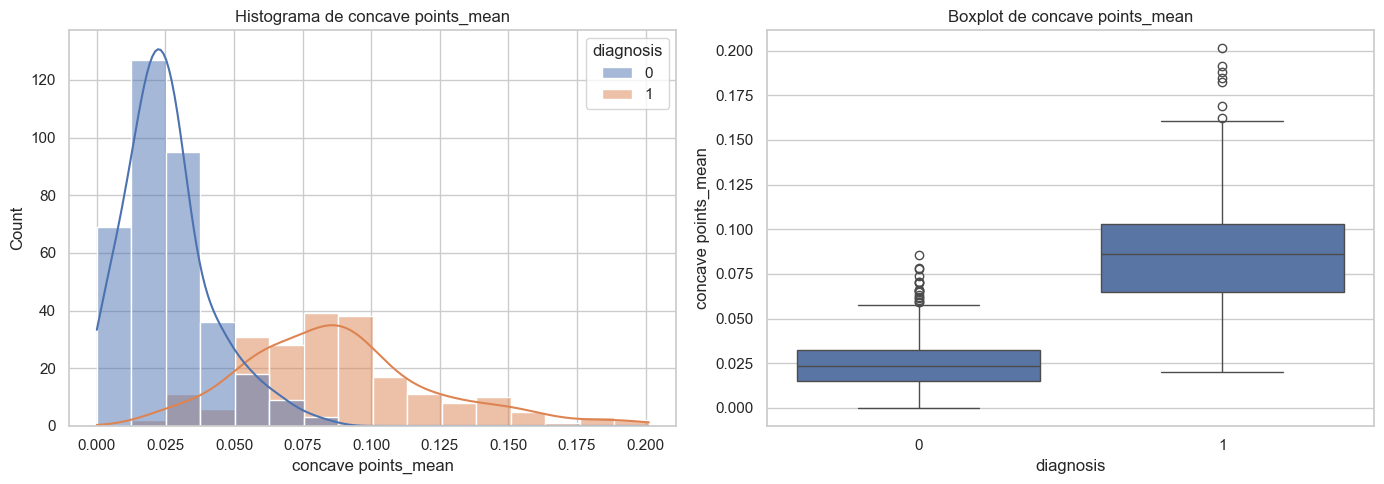

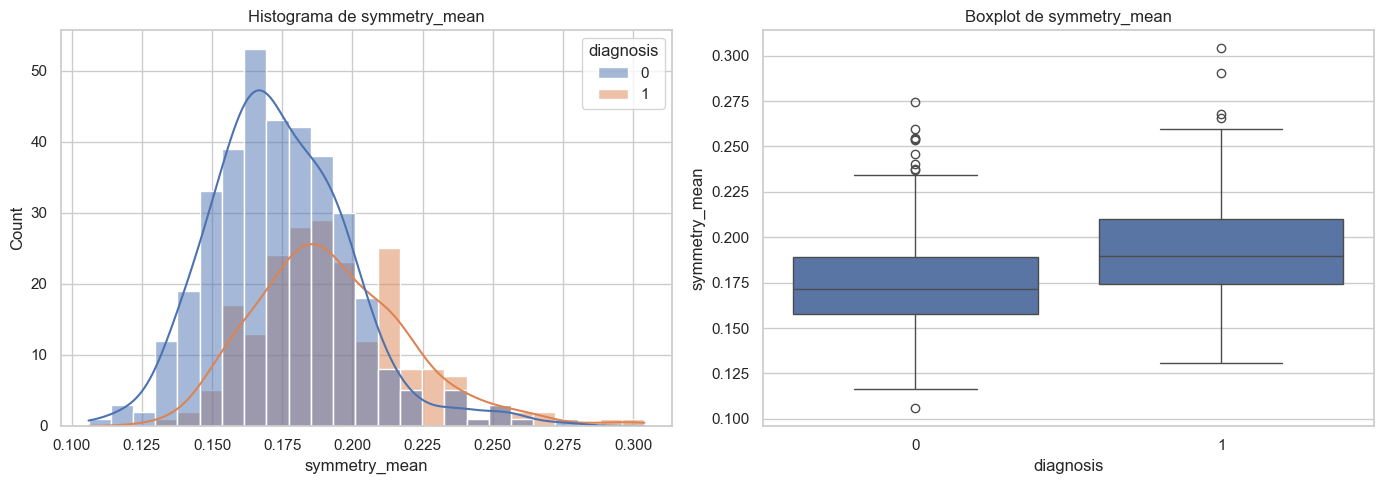

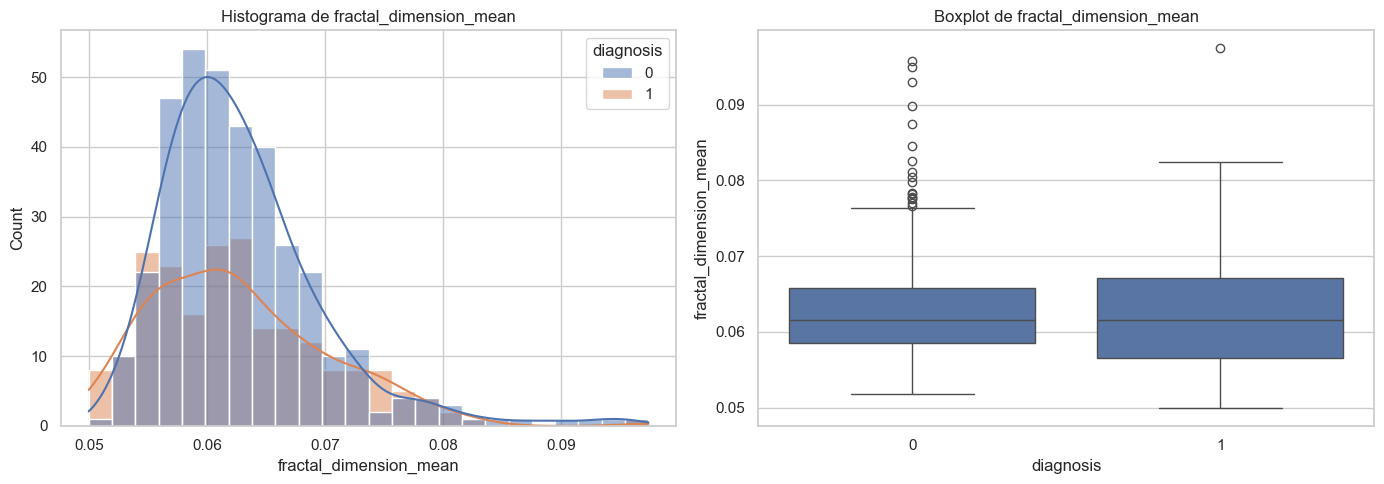

In [60]:
vars_mean = ['texture_mean', 'area_mean', 'smoothness_mean',
             'compactness_mean', 'concavity_mean', 'concave points_mean',
             'symmetry_mean', 'fractal_dimension_mean']

# Histogramas y Boxplots separados para el análisis individual de cada variable
for var in vars_mean:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    sns.histplot(data=df, x=var, hue='diagnosis', kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {var}')

    # Boxplot
    sns.boxplot(data=df, x='diagnosis', y=var, ax=axes[1])
    axes[1].set_title(f'Boxplot de {var}')

    plt.tight_layout()
    plt.show()

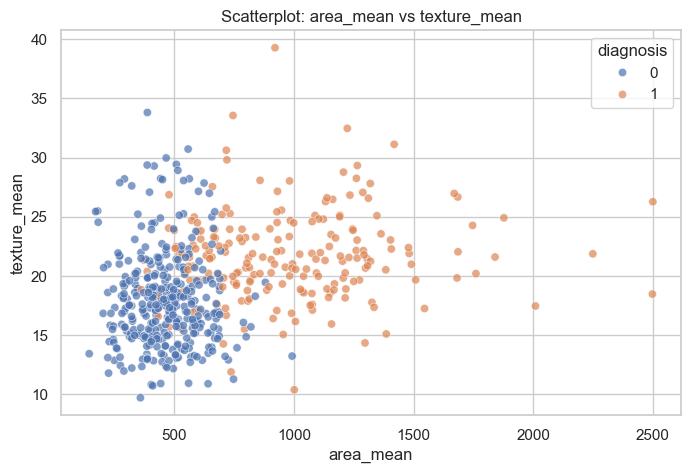

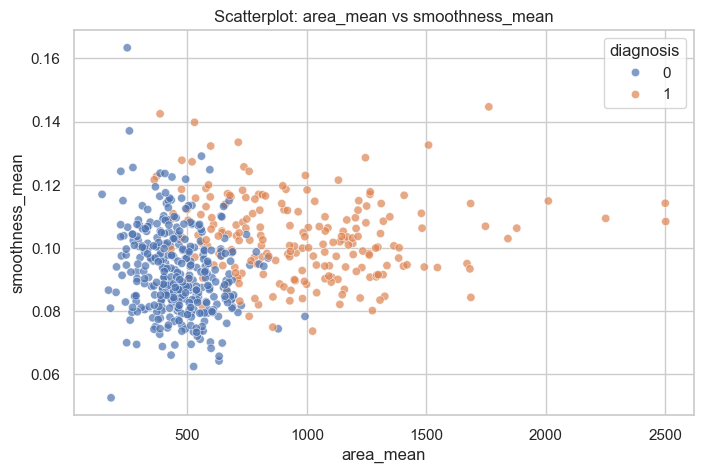

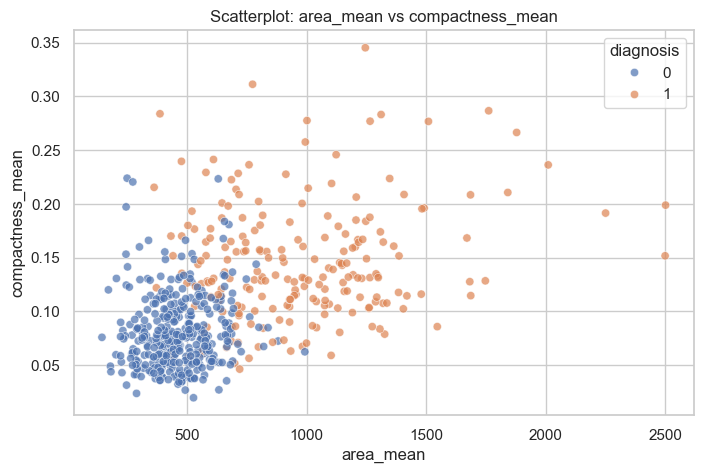

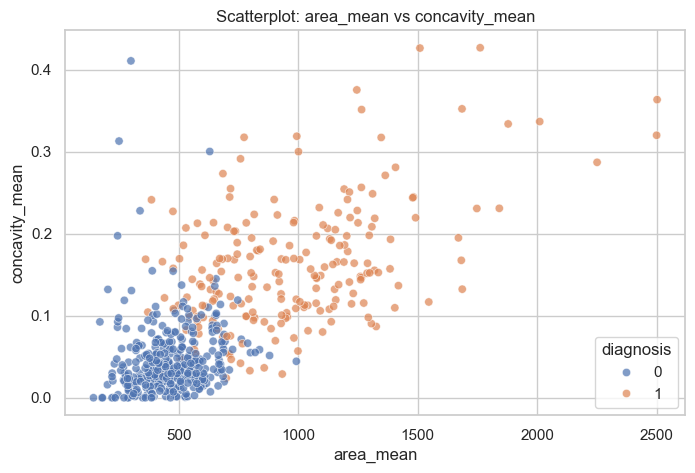

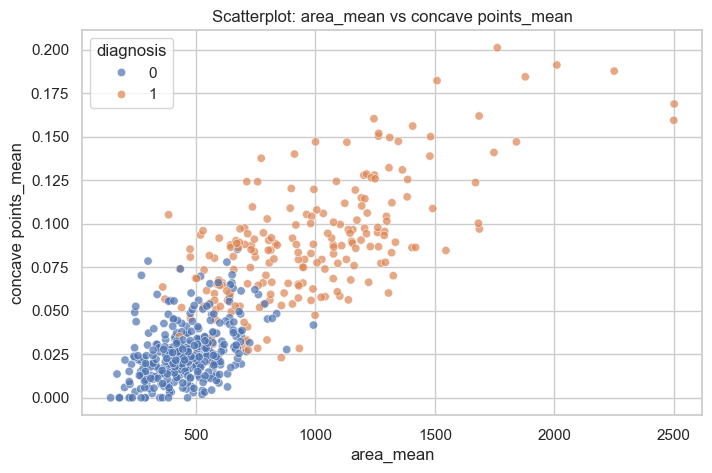

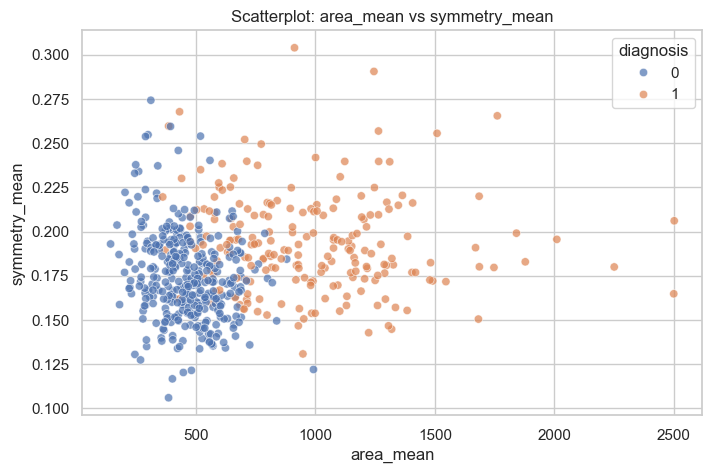

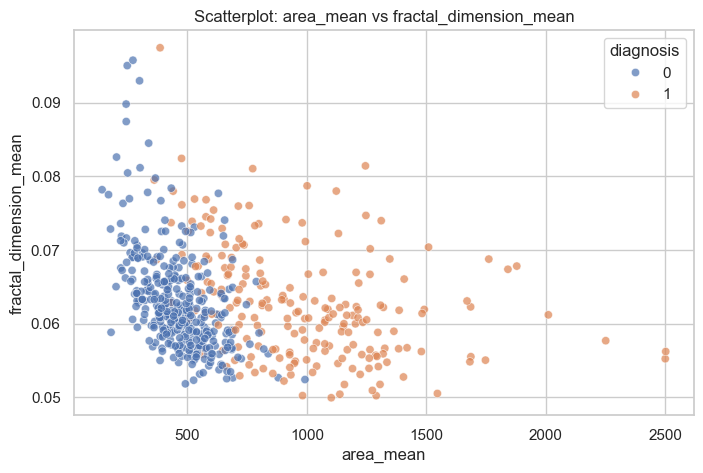

In [61]:
# Scatterplots separados
for var in vars_mean:
    if var != 'area_mean':
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df, x='area_mean', y=var, hue='diagnosis', alpha=0.7)
        plt.title(f'Scatterplot: area_mean vs {var}')
        plt.show()

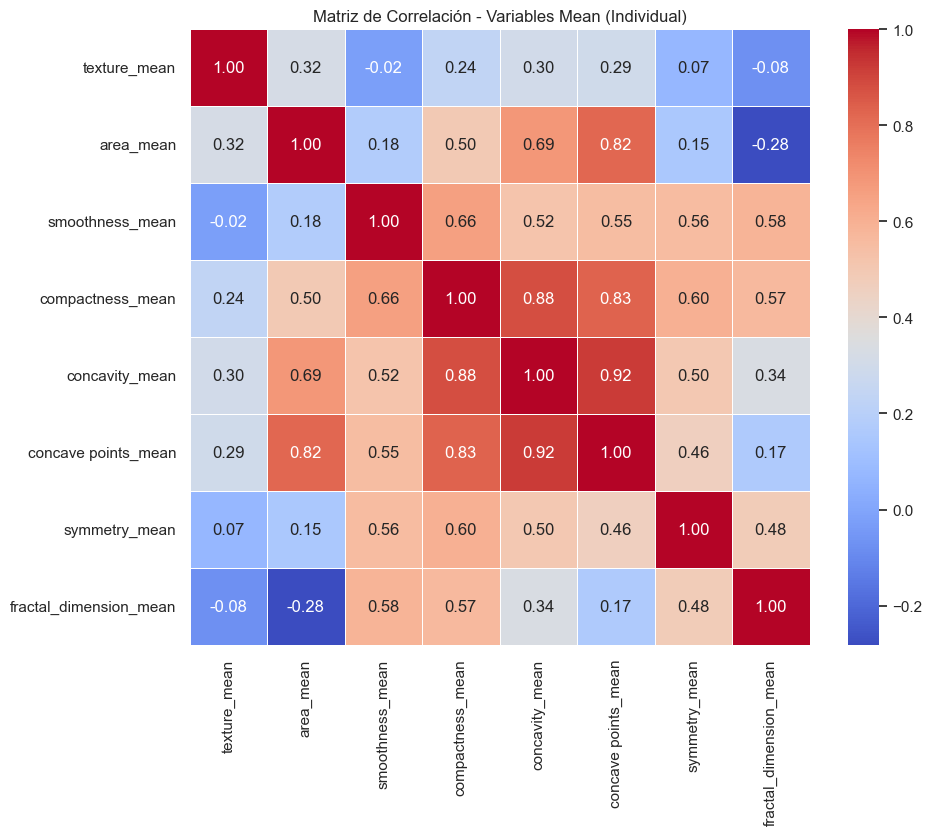

In [62]:
# Matriz de correlación separada
plt.figure(figsize=(10, 8))
corr_matrix = df[vars_mean].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Variables Mean (Individual)')
plt.show()

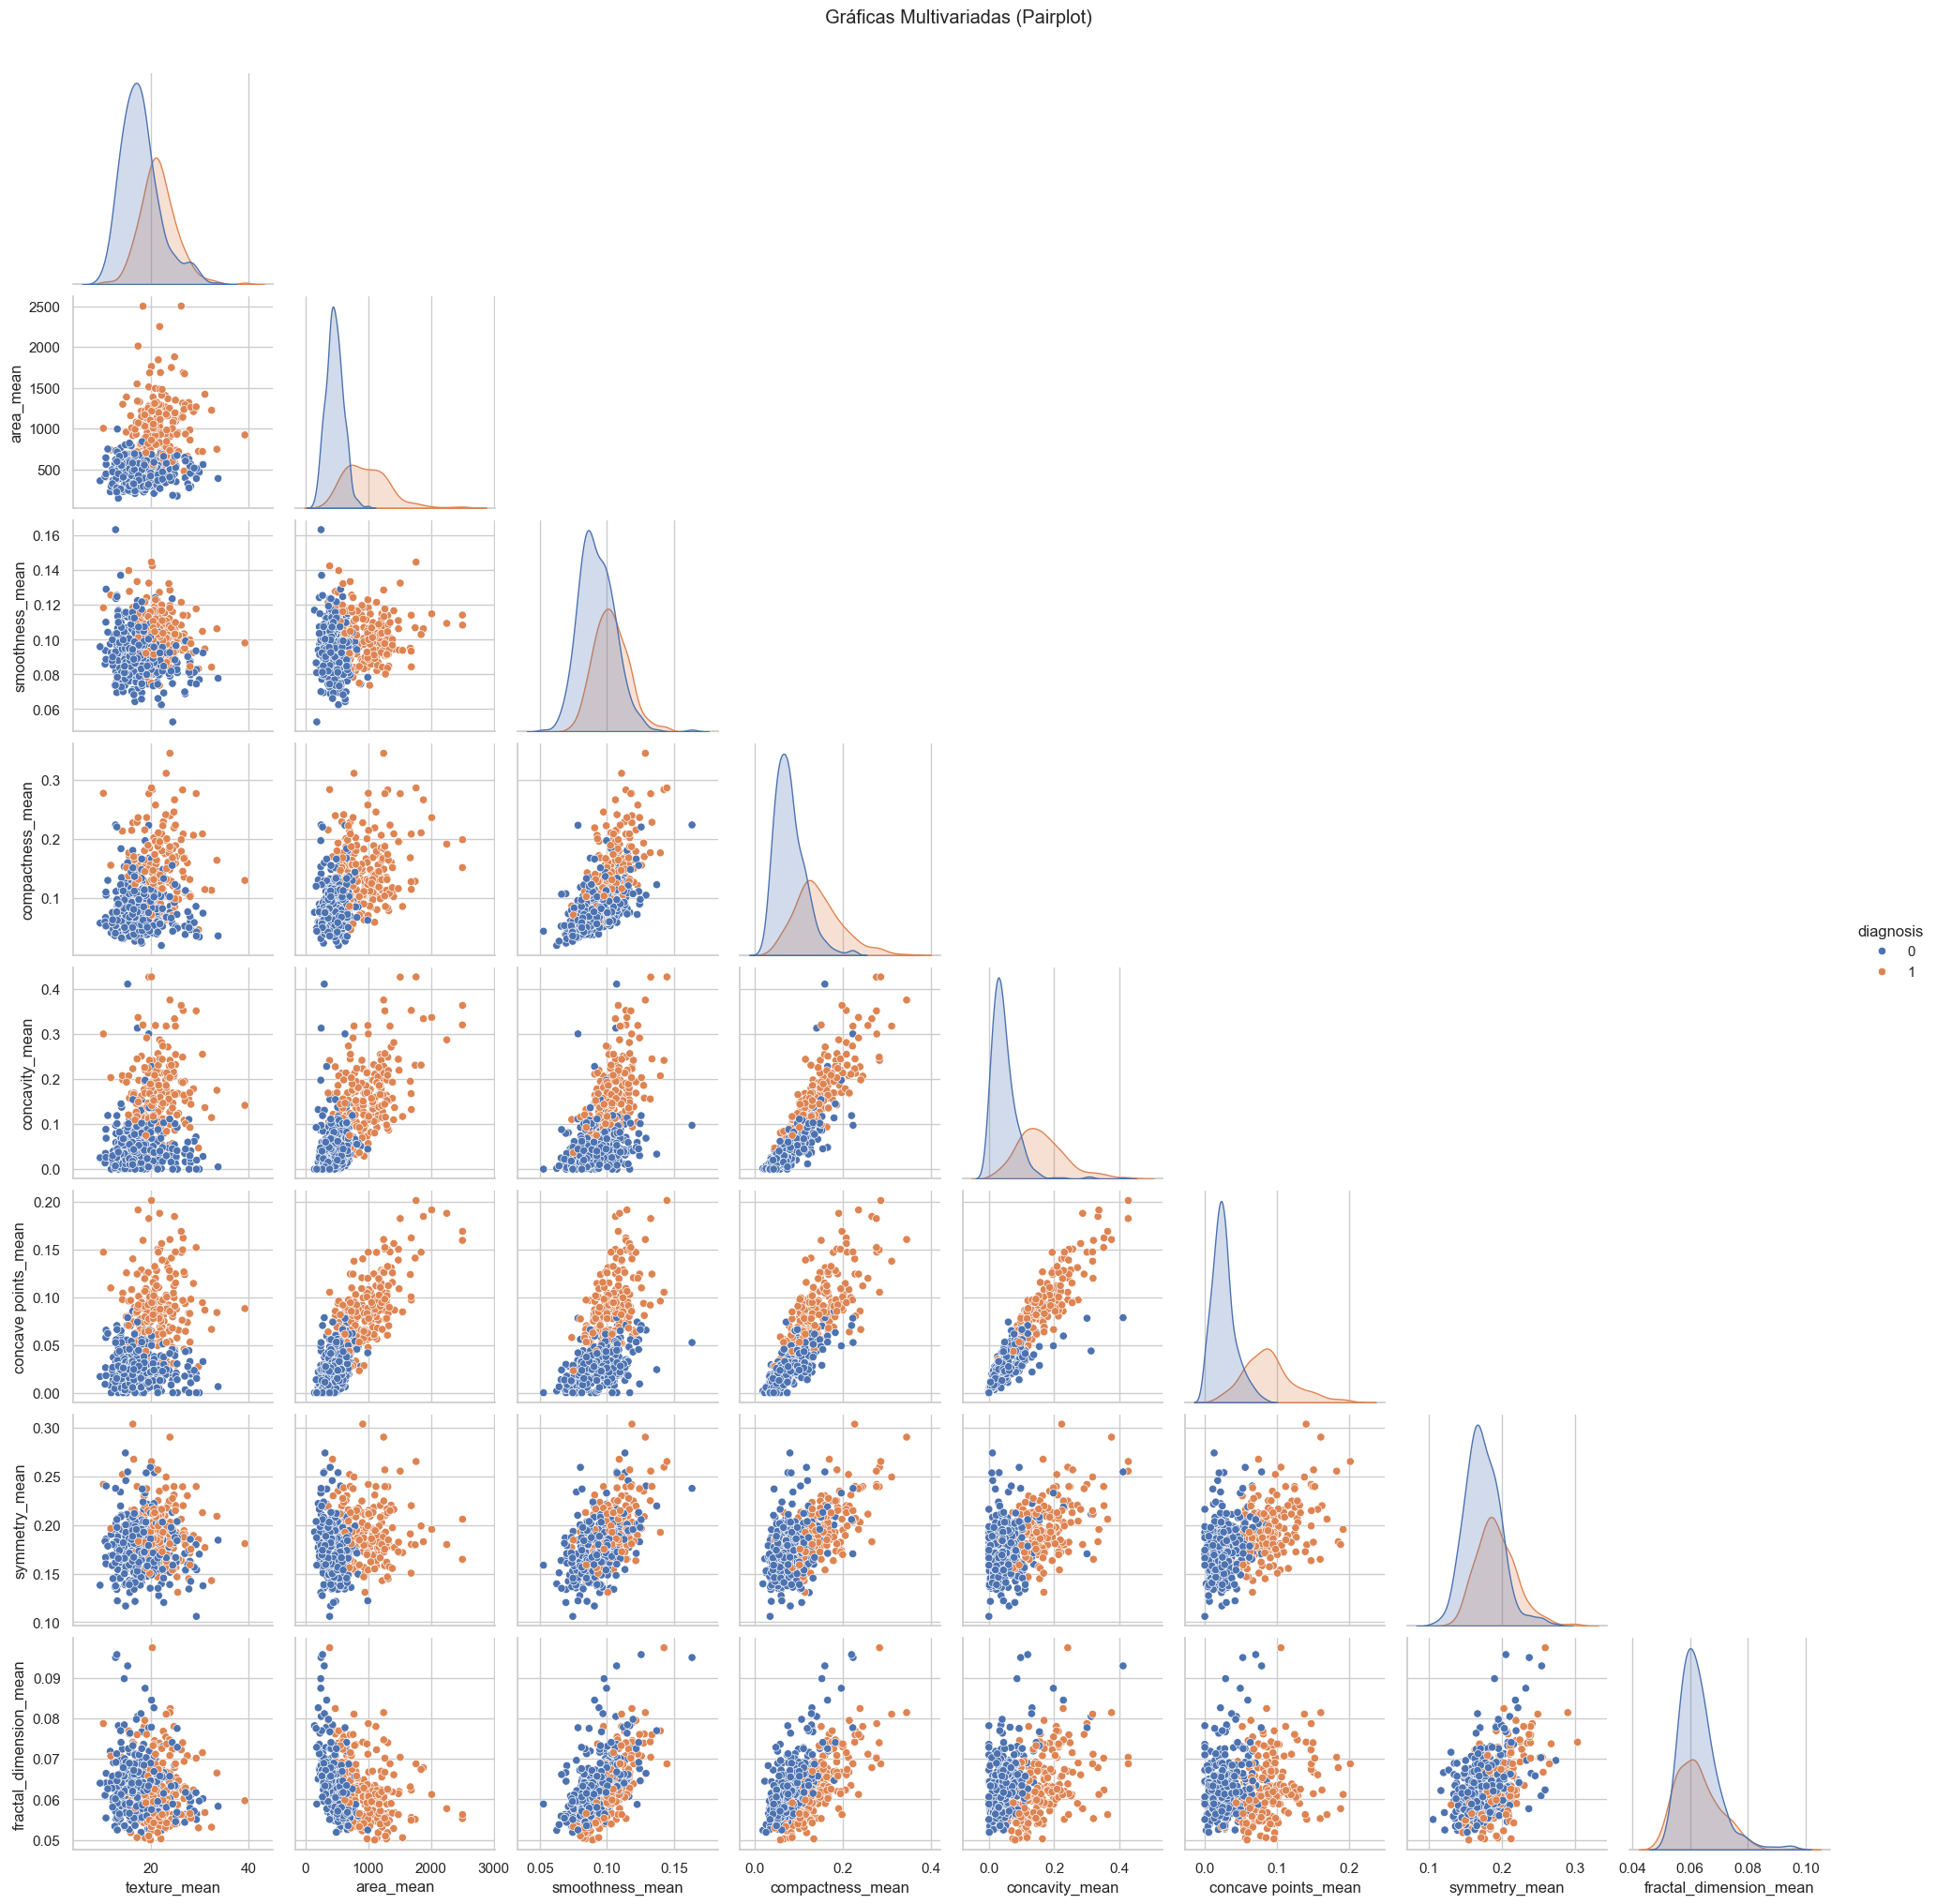

In [63]:
# Gráficas Multivariadas
sns.pairplot(df[vars_mean + ['diagnosis']], hue='diagnosis', corner=True)
plt.suptitle('Gráficas Multivariadas (Pairplot)', y=1.02)
plt.show()

## 2. División de Datos (Data Splitting)
**División de datos:** Separamos los datos en conjuntos de Entrenamiento (Train), Validación (Validation) y Prueba (Test).
El objetivo de **entrenar un modelo** es encontrar patrones en los datos para lograr una buena **generalización**, es decir, que el modelo sea capaz de predecir correctamente sobre datos que nunca ha visto.
Utilizamos la estratificación (`stratify=y`) para mantener la misma proporción de clases (Maligno/Benigno) en todas las particiones.

In [64]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Separar en Train, Validation y Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (398, 30)
Validation: (85, 30)
Test: (86, 30)


## 3. Regresión Logística
En este apartado aplicamos Regresión Logística. Es importante tener en cuenta los conceptos de **Overfitting** (sobreajuste, donde el modelo memoriza el ruido de entrenamiento pero falla en nuevos datos) y **Underfitting** (subajuste, donde el modelo es demasiado simple para capturar los patrones).

Utilizamos un `Pipeline` que primero escala los datos (`StandardScaler`) y luego aplica el modelo. Esto previene el **Data Leakage** (fuga de información) ya que el escalador se ajusta solo con los datos de entrenamiento.

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Crear pipeline con StandardScaler y LogisticRegression
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=500, random_state=42))
])

# Entrenamiento
pipeline_lr.fit(X_train, y_train)
print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


### 3.1 Evaluación del Modelo de Regresión Logística
Evaluamos el modelo utilizando las siguientes métricas:
- **Accuracy (Exactitud):** Porcentaje de predicciones correctas totales.
- **Precision (Precisión):** De las predicciones positivas, ¿cuántas eran realmente positivas?
- **Recall (Sensibilidad):** De todos los positivos reales, ¿cuántos logró encontrar el modelo? En el contexto médico (cáncer), **Recall** es la métrica más importante, ya que un falso negativo puede tener consecuencias mortales.
- **F1-score:** Media armónica entre Precision y Recall.

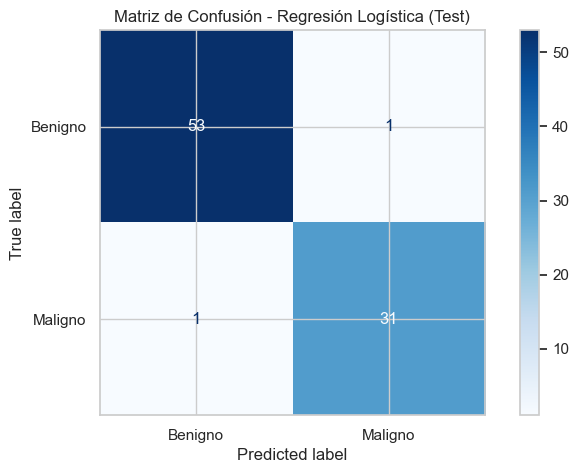

Reporte de Clasificación (Test):
              precision    recall  f1-score   support

     Benigno       0.98      0.98      0.98        54
     Maligno       0.97      0.97      0.97        32

    accuracy                           0.98        86
   macro avg       0.98      0.98      0.98        86
weighted avg       0.98      0.98      0.98        86



In [66]:
# Predicción sobre Test
y_pred_lr = pipeline_lr.predict(X_test)

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Benigno', 'Maligno'])
disp_lr.plot(cmap='Blues')
plt.title("Matriz de Confusión - Regresión Logística (Test)")
plt.show()

print("Reporte de Clasificación (Test):")
print(classification_report(y_test, y_pred_lr, target_names=['Benigno', 'Maligno']))

In [67]:
# Comparación con Train para detectar Overfitting/Underfitting
y_train_pred_lr = pipeline_lr.predict(X_train)
print("Reporte de Clasificación (Train):")
print(classification_report(y_train, y_train_pred_lr, target_names=['Benigno', 'Maligno']))

Reporte de Clasificación (Train):
              precision    recall  f1-score   support

     Benigno       0.98      1.00      0.99       250
     Maligno       1.00      0.97      0.98       148

    accuracy                           0.99       398
   macro avg       0.99      0.98      0.99       398
weighted avg       0.99      0.99      0.99       398



## 3.2 Regresion lineal (variable continua)
Este dataset se usa para clasificacion, pero podemos definir una variable objetivo continua y aplicar regresion lineal siguiendo la metodologia de clase.

### 3.2.1 Seleccion de variable objetivo
Comparamos `area_mean` y `radius_mean` con el mismo procedimiento y elegimos la que tenga mejor $R^2$.
La tabla de resultados muestra las metricas para ambas opciones.

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# Asegurar limpieza coherente con la seccion 1.1
cols_to_drop_nan = [col for col in df.columns if col != "diagnosis" and df[col].isna().all()]
if cols_to_drop_nan:
    df = df.drop(columns=cols_to_drop_nan)

# Funcion de evaluacion para regresion

def evaluar_regresion(nombre, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_real, y_pred)
    return {
        "objetivo": nombre,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# Comparacion de variables objetivo
objetivos = ["area_mean", "radius_mean"]
resultados_objetivos = []

for objetivo in objetivos:
    X_tmp = df.drop(columns=[col for col in ["diagnosis", objetivo] if col in df.columns])
    y_tmp = df[objetivo]

    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X_tmp, y_tmp, test_size=0.30, random_state=42
    )

    modelo_tmp = LinearRegression()
    modelo_tmp.fit(X_train_tmp, y_train_tmp)
    pred_tmp = modelo_tmp.predict(X_test_tmp)

    resultados_objetivos.append(evaluar_regresion(objetivo, y_test_tmp, pred_tmp))

resultados_objetivos = pd.DataFrame(resultados_objetivos).sort_values("R2", ascending=False)
display(resultados_objetivos)

target_regresion = resultados_objetivos.iloc[0]["objetivo"]
print("Objetivo seleccionado:", target_regresion)

,objetivo,MAE,MSE,RMSE,R2
1,radius_mean,0.045611,0.004922,0.070156,0.999597
0,area_mean,13.822703,445.536766,21.107742,0.996029


Objetivo seleccionado: radius_mean


### 3.2.2 Distribucion de la variable objetivo
Antes de entrenar el modelo, revisamos la distribucion de la variable continua seleccionada.

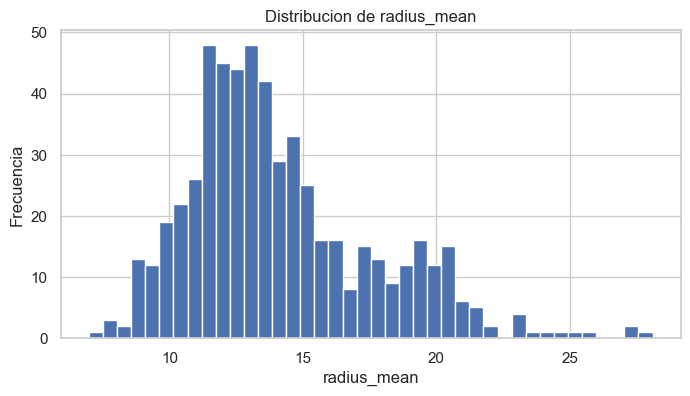

In [69]:
# Distribucion de la variable objetivo
plt.figure(figsize=(8, 4))
plt.hist(df[target_regresion], bins=40)
plt.title(f"Distribucion de {target_regresion}")
plt.xlabel(target_regresion)
plt.ylabel("Frecuencia")
plt.show()

### 3.2.3 Separacion X/y y entrenamiento
Seguimos la misma logica de train/test que en las secciones anteriores.

In [70]:
# Separacion X / y y train-test split
X_reg = df.drop(columns=[col for col in ["diagnosis", target_regresion] if col in df.columns])
y_reg = df[target_regresion]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)

# Entrenamiento del modelo
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_reg, y_train_reg)

# Prediccion y evaluacion
pred_lineal = modelo_lineal.predict(X_test_reg)

resultado_lineal = evaluar_regresion("Regresion lineal", y_test_reg, pred_lineal)
display(pd.DataFrame([resultado_lineal]))

,objetivo,MAE,MSE,RMSE,R2
0,Regresion lineal,0.045611,0.004922,0.070156,0.999597


### 3.2.4 Interpretacion de coeficientes
Los coeficientes indican la direccion del efecto de cada variable sobre la prediccion, manteniendo las demas constantes.

,variable,coeficiente
8,fractal_dimension_mean,4.159981
16,concave points_se,2.125556
17,symmetry_se,1.820648
3,smoothness_mean,1.671557
15,concavity_se,1.445980
7,symmetry_mean,0.455708
24,compactness_worst,0.271507
9,radius_se,0.182260
19,radius_worst,0.164373
26,concave points_worst,0.145017


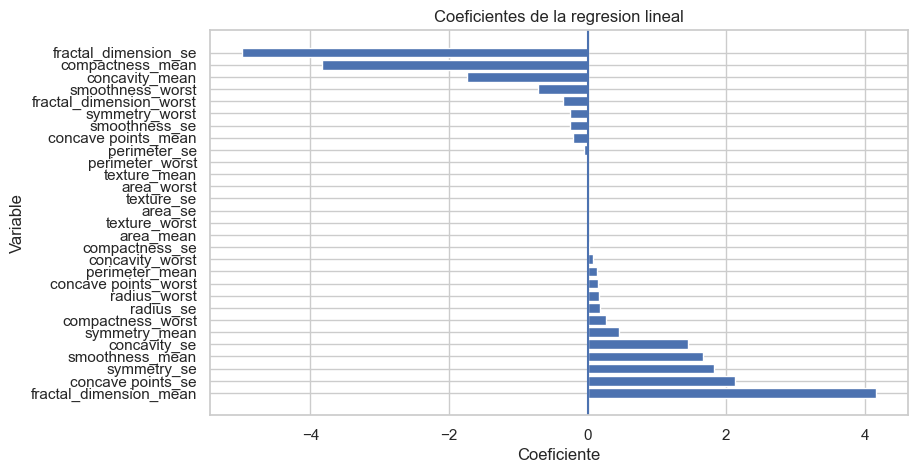

In [71]:
# Coeficientes del modelo
coeficientes_lineal = pd.DataFrame({
    "variable": X_reg.columns,
    "coeficiente": modelo_lineal.coef_
}).sort_values("coeficiente", ascending=False)

display(coeficientes_lineal)

plt.figure(figsize=(9, 5))
plt.barh(coeficientes_lineal["variable"], coeficientes_lineal["coeficiente"])
plt.title("Coeficientes de la regresion lineal")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.axvline(0)
plt.show()

### 3.2.5 Diagnostico visual: real vs predicho
Si el modelo fuera perfecto, los puntos caerian sobre la diagonal.

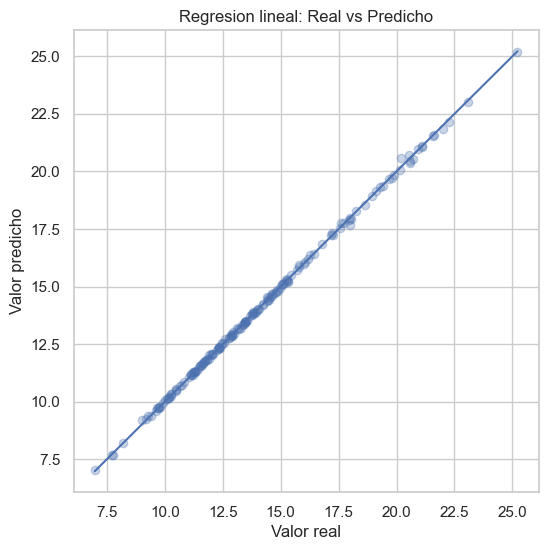

In [72]:
# Real vs Predicho
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, pred_lineal, alpha=0.3)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Regresion lineal: Real vs Predicho")

min_val = min(y_test_reg.min(), pred_lineal.min())
max_val = max(y_test_reg.max(), pred_lineal.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

### 3.2.6 Analisis de residuos
El residuo es la diferencia entre el valor real y el valor predicho. Revisamos su distribucion y si hay patrones evidentes.

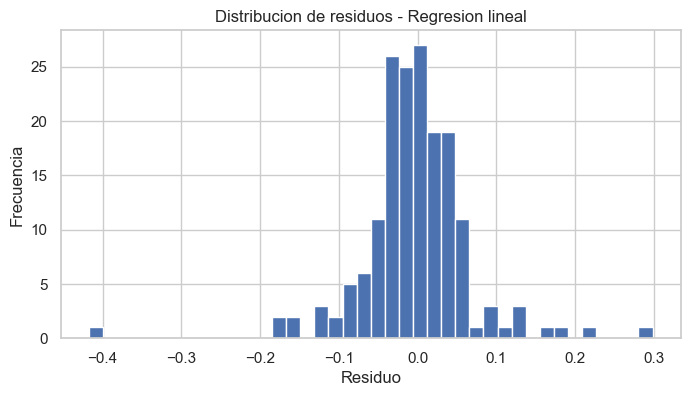

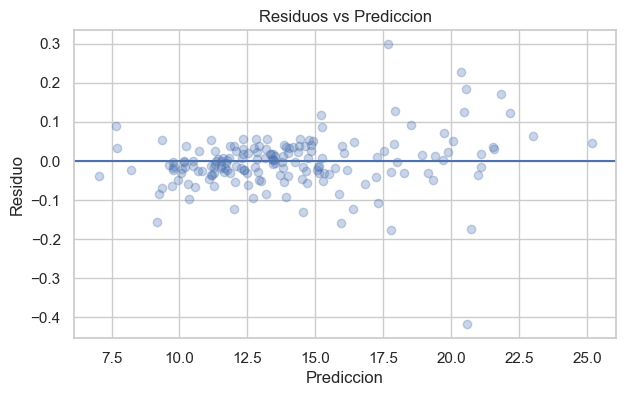

In [73]:
# Analisis de residuos
residuos_lineal = y_test_reg - pred_lineal

plt.figure(figsize=(8, 4))
plt.hist(residuos_lineal, bins=40)
plt.title("Distribucion de residuos - Regresion lineal")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(pred_lineal, residuos_lineal, alpha=0.3)
plt.axhline(0)
plt.title("Residuos vs Prediccion")
plt.xlabel("Prediccion")
plt.ylabel("Residuo")
plt.show()

### 3.2.7 Analisis de resultados
A continuacion se resumen las metricas MAE, RMSE y $R^2$ y se interpreta el ajuste del modelo con base en los resultados obtenidos.

In [74]:
# Métricas
mae = resultado_lineal["MAE"]
rmse = resultado_lineal["RMSE"]
r2 = resultado_lineal["R2"]
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MAE: 0.0456
RMSE: 0.0702
R2: 0.9996


**Resumen de metricas**
- MAE: 0.0461
- RMSE: 0.0707
- R^2: 0.9996

**Lectura de graficas**
- Distribucion del objetivo: se observa una concentracion principal y cola hacia valores altos, lo que explica algunos errores mas grandes.
- Real vs predicho: los puntos se alinean cerca de la diagonal, indicando buen ajuste global.
- Histograma de residuos: centrado en 0 y relativamente simetrico, sin sesgo fuerte.
- Residuos vs prediccion: dispersion moderada; si hay abanico en valores altos, sugiere ligera heterocedasticidad.

**Conclusion**
- El modelo lineal explica casi toda la variabilidad del objetivo y los errores son bajos.
- No se observan patrones fuertes en residuos, por lo que el ajuste lineal es adecuado para este conjunto.

## 4. Árboles de Decisión
En esta sección aplicamos un modelo de Árboles de Decisión. Estos modelos toman decisiones basadas en reglas extraídas de las características.

### 4.1 Conceptos de Impureza
Los árboles buscan la mejor división utilizando medidas de impureza como **Gini** o **Entropía**.

In [75]:
def gini(proporciones):
    return 1 - sum([p**2 for p in proporciones])

def entropia(proporciones):
    resultado = 0
    for p in proporciones:
        if p > 0:
            resultado -= p * np.log2(p)
    return resultado

ejemplos = {
    "Nodo puro [1.0, 0.0]": [1.0, 0.0],
    "Nodo 50/50 [0.5, 0.5]": [0.5, 0.5],
    "Nodo 80/20 [0.8, 0.2]": [0.8, 0.2],
    "Nodo 90/10 [0.9, 0.1]": [0.9, 0.1]
}

print("Cálculos teóricos de impureza:")
for nombre, props in ejemplos.items():
    print(nombre, "| Gini:", round(gini(props), 3), "| Entropía:", round(entropia(props), 3))

Cálculos teóricos de impureza:
Nodo puro [1.0, 0.0] | Gini: 0.0 | Entropía: 0.0
Nodo 50/50 [0.5, 0.5] | Gini: 0.5 | Entropía: 1.0
Nodo 80/20 [0.8, 0.2] | Gini: 0.32 | Entropía: 0.722
Nodo 90/10 [0.9, 0.1] | Gini: 0.18 | Entropía: 0.469


### 4.2 Entrenamiento del Árbol Base
Creamos un árbol de decisión base, limitando su profundidad máxima a 3 (`max_depth=3`) para evitar sobreajuste y facilitar su interpretación.

In [76]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

arbol_base = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

arbol_base.fit(X_train, y_train)
print("Árbol base entrenado correctamente.")

Árbol base entrenado correctamente.


### 4.3 Evaluación del Árbol Base

Accuracy: 0.9302
Precision: 1.0
Recall: 0.8125
F1-score: 0.8966

Reporte completo:
              precision    recall  f1-score   support

     Benigno       0.90      1.00      0.95        54
     Maligno       1.00      0.81      0.90        32

    accuracy                           0.93        86
   macro avg       0.95      0.91      0.92        86
weighted avg       0.94      0.93      0.93        86



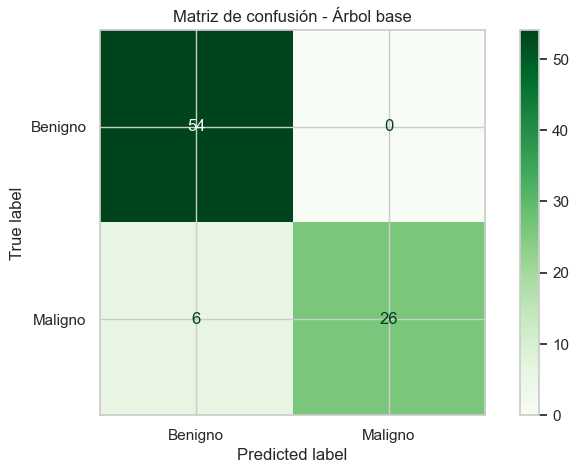

In [77]:
y_pred_tree = arbol_base.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_tree), 4))
print("Precision:", round(precision_score(y_test, y_pred_tree), 4))
print("Recall:", round(recall_score(y_test, y_pred_tree), 4))
print("F1-score:", round(f1_score(y_test, y_pred_tree), 4))

print("\nReporte completo:")
print(classification_report(y_test, y_pred_tree, target_names=['Benigno', 'Maligno']))

cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Benigno', 'Maligno'])
disp_tree.plot(cmap='Greens')
plt.title("Matriz de confusión - Árbol base")
plt.show()

### 4.4 Visualización del Árbol y Reglas

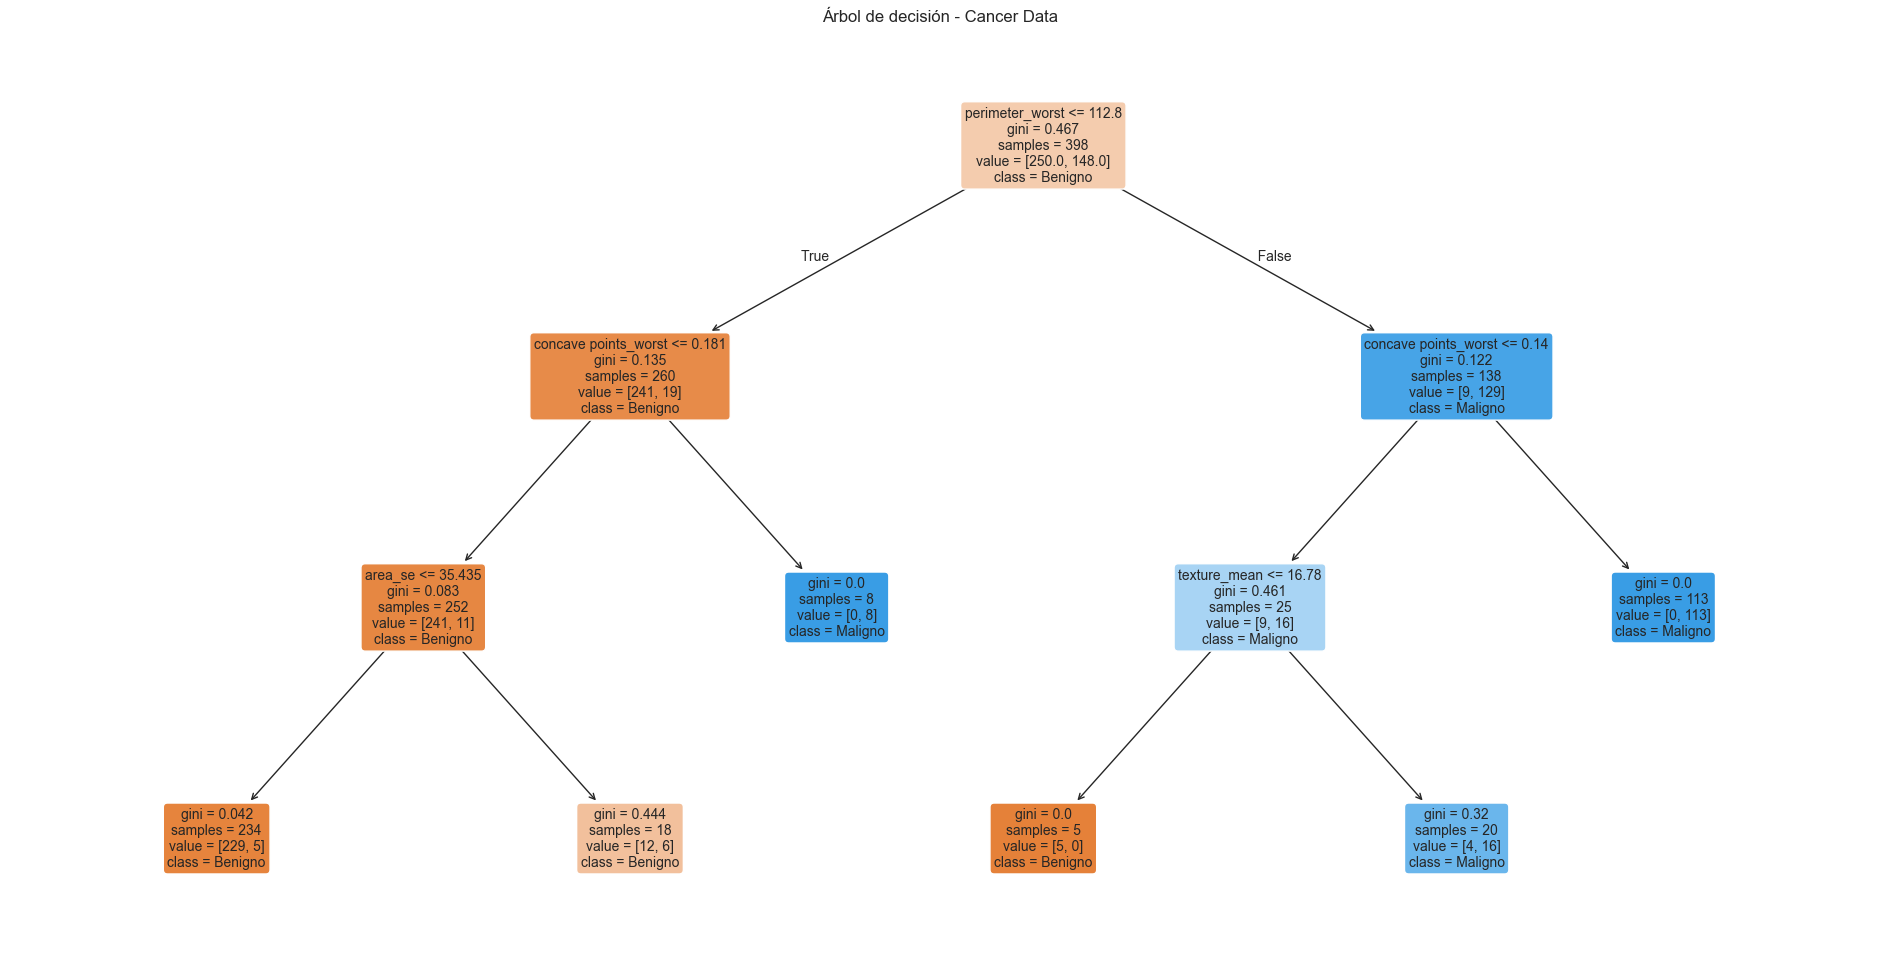

In [78]:
plt.figure(figsize=(24, 12))

plot_tree(
    arbol_base,
    feature_names=list(X.columns),
    class_names=['Benigno', 'Maligno'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de decisión - Cancer Data")
plt.show()

In [79]:
reglas = export_text(arbol_base, feature_names=list(X.columns))
print("Reglas del Árbol:")
print(reglas)

Reglas del Árbol:
|--- perimeter_worst <= 112.80
|   |--- concave points_worst <= 0.18
|   |   |--- area_se <= 35.44
|   |   |   |--- class: 0
|   |   |--- area_se >  35.44
|   |   |   |--- class: 0
|   |--- concave points_worst >  0.18
|   |   |--- class: 1
|--- perimeter_worst >  112.80
|   |--- concave points_worst <= 0.14
|   |   |--- texture_mean <= 16.78
|   |   |   |--- class: 0
|   |   |--- texture_mean >  16.78
|   |   |   |--- class: 1
|   |--- concave points_worst >  0.14
|   |   |--- class: 1



### 4.5 Importancia de las Variables
Vemos cuáles son las características que el árbol considera más importantes para separar las clases.

,variable,importancia
22,perimeter_worst,0.827734
27,concave points_worst,0.120496
1,texture_mean,0.031655
13,area_se,0.020114
2,perimeter_mean,0.000000
3,area_mean,0.000000
5,compactness_mean,0.000000
6,concavity_mean,0.000000
8,symmetry_mean,0.000000
7,concave points_mean,0.000000


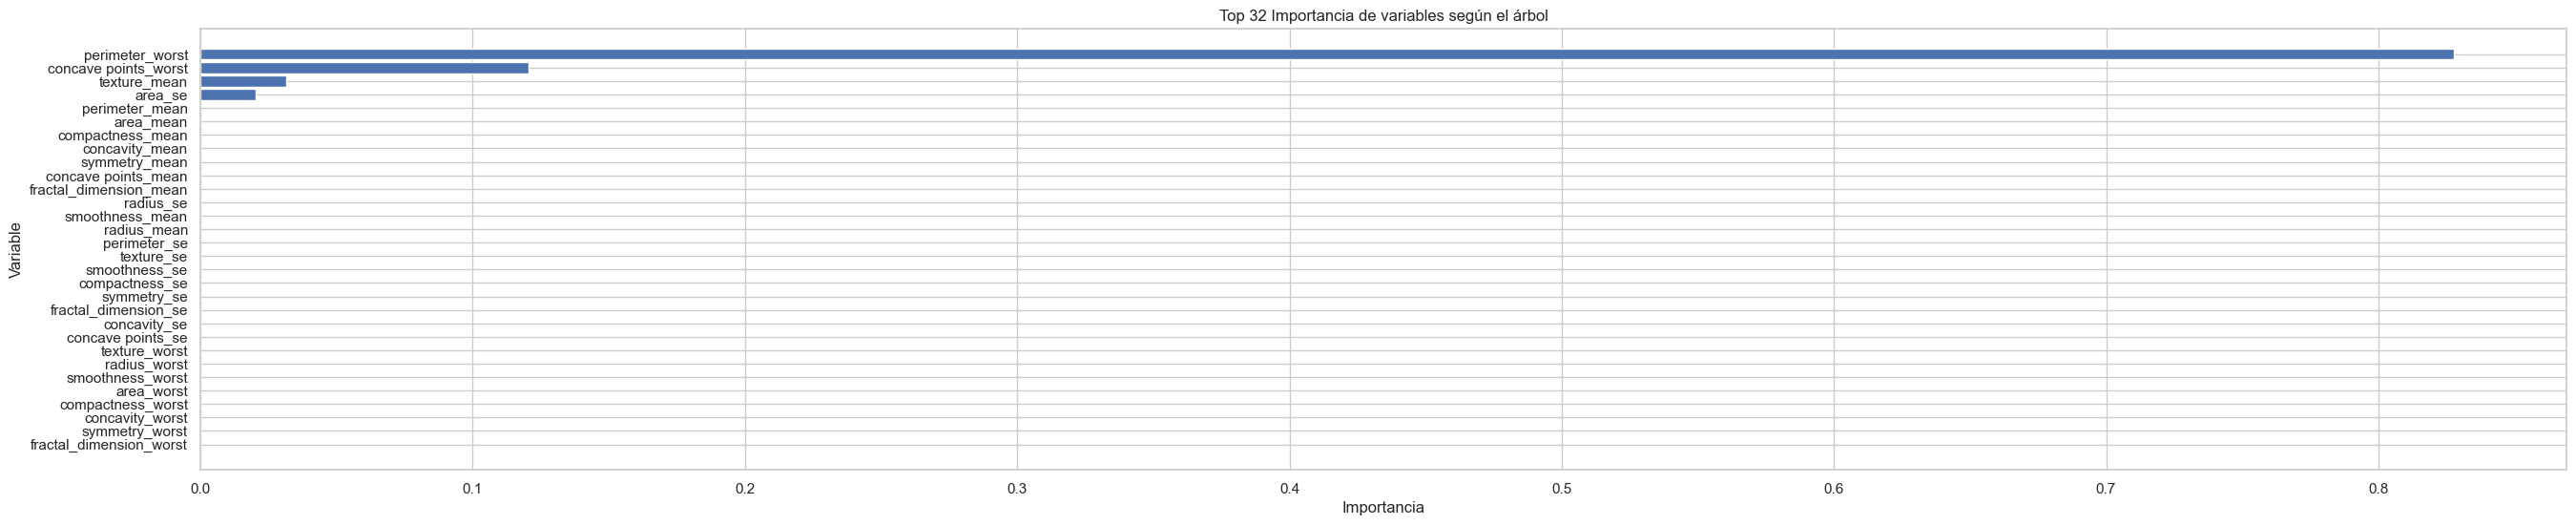

In [80]:
importancias = pd.DataFrame({
    "variable": X.columns,
    "importancia": arbol_base.feature_importances_
}).sort_values("importancia", ascending=False)

display(importancias.head(32))

plt.figure(figsize=(32, 6))
plt.barh(importancias["variable"][:32], importancias["importancia"][:32])
plt.gca().invert_yaxis()
plt.title("Top 32 Importancia de variables según el árbol")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

### 4.6 Efecto de la Profundidad del Árbol (Overfitting vs Generalización)
Si dejamos que el árbol crezca demasiado (`max_depth` alto), se ajustará perfectamente al set de entrenamiento pero perderá rendimiento en los datos de test.

In [81]:
profundidades = [1, 2, 3, 4, 5, 6, 8, 10, None]
resultados = []

for p in profundidades:
    modelo = DecisionTreeClassifier(
        criterion="gini",
        max_depth=p,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    resultados.append({
        "max_depth": str(p),
        "accuracy_train": accuracy_score(y_train, pred_train),
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_test": f1_score(y_test, pred_test)
    })

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

,max_depth,accuracy_train,accuracy_test,f1_test
0,1,0.929648,0.906977,0.862069
1,2,0.949749,0.930233,0.900000
2,3,0.962312,0.930233,0.896552
3,4,0.977387,0.918605,0.881356
4,5,0.984925,0.930233,0.900000
5,6,0.992462,0.941860,0.918033
6,8,1.000000,0.906977,0.875000
7,10,1.000000,0.906977,0.875000
8,None,1.000000,0.906977,0.875000


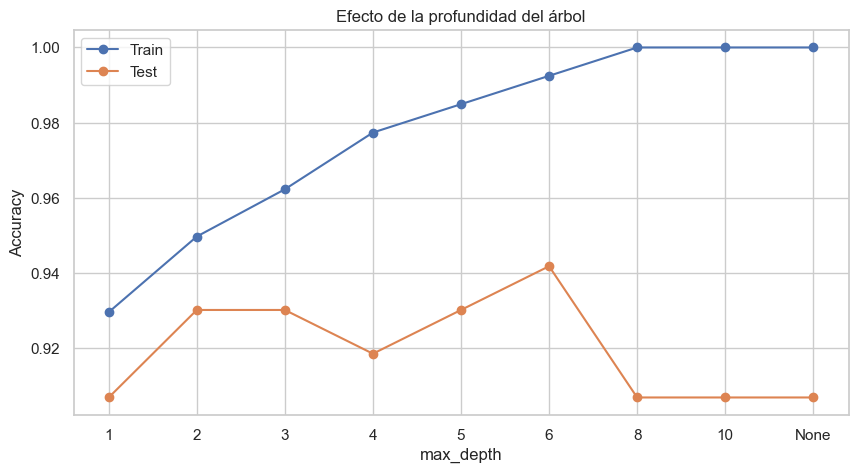

In [82]:
plt.figure(figsize=(10,5))
plt.plot(df_resultados["max_depth"].astype(str), df_resultados["accuracy_train"], marker="o", label="Train")
plt.plot(df_resultados["max_depth"].astype(str), df_resultados["accuracy_test"], marker="o", label="Test")
plt.title("Efecto de la profundidad del árbol")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### 4.7 Comparación Gini vs Entropía

In [83]:
comparacion = []

for criterio in ["gini", "entropy"]:
    modelo = DecisionTreeClassifier(
        criterion=criterio,
        max_depth=3,
        random_state=42
    )

    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    comparacion.append({
        "criterio": criterio,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })

display(pd.DataFrame(comparacion))

,criterio,accuracy,precision,recall,f1
0,gini,0.930233,1.0,0.8125,0.896552
1,entropy,0.930233,1.0,0.8125,0.896552


## 5. Conclusiones
- Se implementó correctamente una estructura de preprocesamiento, escalado de datos (en el caso de la Regresión Logística), y división controlada.
- Se ha evidenciado la diferencia de rendimiento de distintos modelos y configuraciones de hiperparámetros.
- La Regresión Logística muestra una mayor estabilidad debido a la penalización inherente, mientras que los Árboles de Decisión requieren limitar su profundidad para no caer en Overfitting.
- Como siguiente paso, se podrían probar modelos más avanzados basados en ensambles como Random Forest o Gradient Boosting.

# K-Nearest Neighbors (KNN) - Dataset de Cáncer

## Objetivo

Entrenar, evaluar y comparar un modelo KNN usando el dataset `Cancer_Data.csv`.

## Parte A — Comprensión conceptual

Responda:

1.  **¿Qué significa KNN?**
    *   _Respuesta:_

2.  **¿Cómo clasifica KNN un nuevo registro?**
    *   _Respuesta:_

3.  **¿Qué representa el parámetro \(k\)?**
    *   _Respuesta:_

4.  **¿Por qué KNN depende de la distancia?**
    *   _Respuesta:_

5.  **¿Por qué el escalado es obligatorio o muy recomendable?**
    *   _Respuesta:_

6.  **¿Qué diferencia conceptual hay entre KNN y árbol de decisión?**
    *   _Respuesta:_

1.  **¿Qué significa KNN?**
    *   _Respuesta:_ KNN significa "K-Nearest Neighbors" (K-Vecinos Más Cercanos). Es un algoritmo de aprendizaje supervisado no paramétrico que se utiliza para tareas de clasificación y regresión.

2.  **¿Cómo clasifica KNN un nuevo registro?**
    *   _Respuesta:_ Para clasificar un nuevo registro, KNN calcula la distancia entre este registro y todos los puntos de datos en el conjunto de entrenamiento. Luego, selecciona los 'k' vecinos más cercanos. La clase del nuevo registro se determina por la mayoría de las clases entre esos 'k' vecinos. En el caso de regresión, se toma la media de los valores de los 'k' vecinos.

3.  **¿Qué representa el parámetro \(k\)?**
    *   _Respuesta:_ El parámetro \(k\) representa el número de vecinos más cercanos que se consideran al clasificar un nuevo punto de datos. Es un hiperparámetro que debe ser ajustado, ya que un valor de \(k\) demasiado pequeño puede hacer que el modelo sea sensible al ruido (sobreajuste), y un valor demasiado grande puede hacer que ignore los patrones locales (subajuste).

4.  **¿Por qué KNN depende de la distancia?**
    *   _Respuesta:_ KNN depende fundamentalmente de la distancia porque su mecanismo de clasificación se basa en la proximidad. La distancia (comúnmente euclidiana, pero pueden usarse otras) es la métrica que define qué tan "cercanos" son los vecinos. Sin una medida de distancia, el algoritmo no podría identificar los "K-Nearest Neighbors".

5.  **¿Por qué el escalado es obligatorio o muy recomendable?**
    *   _Respuesta:_ El escalado de características es obligatorio o muy recomendable para KNN porque el algoritmo es sensible a la escala de las características. Si las características tienen rangos de valores muy diferentes, aquellas con rangos más grandes dominarán desproporcionadamente el cálculo de la distancia, haciendo que las características con rangos más pequeños sean casi irrelevantes. El escalado (por ejemplo, normalización o estandarización) asegura que todas las características contribuyan equitativamente a la medida de distancia.

6.  **¿Qué diferencia conceptual hay entre KNN y árbol de decisión?**
    *   _Respuesta:_ La principal diferencia conceptual radica en cómo aprenden y clasifican. Un **Árbol de Decisión** es un modelo basado en reglas que crea una estructura jerárquica de divisiones para segmentar el espacio de características, lo que resulta en una serie de reglas condicionales (si-entonces) que son fácilmente interpretables. Es un modelo "eager learning" (aprende antes de ver los datos de test). Por otro lado, **KNN** es un algoritmo basado en instancias o "lazy learning" (aprende cuando se le pide una predicción). No construye un modelo explícito durante el entrenamiento, sino que almacena todo el conjunto de datos de entrenamiento y clasifica un nuevo punto consultando a sus vecinos más cercanos en ese momento. Los árboles definen límites de decisión complejos, mientras que KNN define límites implícitamente basados en la densidad de puntos en el espacio de características.

## Parte B — Preparación de datos

Para este taller, utilizaremos todas las características numéricas del dataset `df` (excluyendo la columna `diagnosis` como variable objetivo). El dataset ya fue cargado, sus columnas limpiadas, la columna `id` y la columna vacía eliminadas, y la variable `diagnosis` codificada a 0 y 1 en las secciones anteriores del notebook.

Ahora, realizaremos la separación en conjuntos de entrenamiento y prueba (train/test split) con estratificación para asegurar una representación equitativa de las clases de diagnóstico en ambos conjuntos.

In [84]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# --- START: Código para asegurar que df esté definido y limpio para el taller ---
# Cargar el dataset para asegurar un estado fresco del DataFrame
file_path = 'Cancer_Data.csv'

# Check if the file exists in the current directory first, then in /content/sample_data/
if not os.path.exists(file_path):
    file_path = '/content/sample_data/Cancer_Data.csv'

df = pd.read_csv(file_path)

# Limpiar nombres de columnas (eliminar espacios y comillas)
df.columns = df.columns.str.replace('"', '').str.strip()

# Limpiar valores de texto en todo el dataframe (ej: " M " -> "M")
# Usando applymap para mayor compatibilidad con la versión original.
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# Identificar y eliminar columnas con solo NaNs (más robusto)
cols_to_drop_nan = [col for col in df.columns if col != 'diagnosis' and df[col].isna().all()]
if cols_to_drop_nan:
    df.drop(columns=cols_to_drop_nan, inplace=True)

# Codificar la variable objetivo (Maligno = 1, Benigno = 0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
# --- END: Código para asegurar que df esté definido y limpio para el taller ---

# X y y son derivados del df limpio para el taller
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Realizamos un nuevo train/test split para este taller para seguir la estructura de la consigna
X_taller, X_temp, y_taller, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# La consigna del taller solo pide train/test, así que usaremos X_taller y y_taller
# como el conjunto completo para este taller, y luego haremos un 70/30 de nuevo.

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Dimensiones del conjunto de entrenamiento:", X_train_t.shape, y_train_t.shape)
print("Dimensiones del conjunto de prueba:", X_test_t.shape, y_test_t.shape)


Dimensiones del conjunto de entrenamiento: (398, 31) (398,)
Dimensiones del conjunto de prueba: (171, 31) (171,)


## Helper Function: `evaluar_modelo`

Para simplificar la evaluación y comparación de los modelos, definiremos una función auxiliar que calcula las métricas de clasificación (accuracy, precision, recall, f1-score) y las retorna en un diccionario. Esto nos permitirá tener un formato consistente para todas las comparaciones.

In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluar_modelo(nombre_modelo, y_true, y_pred):
    """Calcula y retorna métricas de evaluación para un modelo."""
    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }


## Parte C — KNN sin escalado vs KNN con escalado

Entrenaremos y evaluaremos el modelo KNN con \(k=5\), primero sin escalar las características y luego aplicando un `StandardScaler` dentro de un `Pipeline`. Compararemos las métricas de rendimiento y discutiremos la importancia del escalado en KNN.

### Explicación:
*   **KNN sin escalado:** Se entrena el modelo directamente con los datos `X_train_t` y `y_train_t` sin ninguna transformación de las características.
*   **KNN con escalado:** Se utiliza un `Pipeline` que primero aplica `StandardScaler` a los datos (para estandarizarlos a media 0 y varianza 1) y luego entrena el `KNeighborsClassifier`. El escalado es crucial para KNN porque este algoritmo se basa en distancias. Si las características tienen rangos de valores muy diferentes, las características con rangos más grandes dominarán la métrica de distancia, sesgando los resultados.

In [86]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# KNN sin escalado
knn_sin = KNeighborsClassifier(n_neighbors=5)
knn_sin.fit(X_train_t, y_train_t)
pred_sin = knn_sin.predict(X_test_t)

# KNN con escalado usando Pipeline
knn_con = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn_con.fit(X_train_t, y_train_t)
pred_con = knn_con.predict(X_test_t)

# Comparación de resultados
comparacion_taller_knn = pd.DataFrame([
    evaluar_modelo("KNN sin escalado", y_test_t, pred_sin),
    evaluar_modelo("KNN con escalado", y_test_t, pred_con)
])

display(comparacion_taller_knn)

print("\nMetodológicamente, la versión con escalado es más correcta porque el KNN se basa en la distancia entre los puntos. Sin escalado, las características con rangos de valores más grandes pueden dominar la métrica de distancia, llevando a resultados sesgados y un rendimiento subóptimo.")

,Modelo,Accuracy,Precision,Recall,F1-score
0,KNN sin escalado,0.695906,0.714286,0.31250,0.434783
1,KNN con escalado,0.964912,1.000000,0.90625,0.950820



Metodológicamente, la versión con escalado es más correcta porque el KNN se basa en la distancia entre los puntos. Sin escalado, las características con rangos de valores más grandes pueden dominar la métrica de distancia, llevando a resultados sesgados y un rendimiento subóptimo.


## Parte D — Selección de k

Exploraremos el impacto del valor de \(k\) (el número de vecinos) en el rendimiento del modelo KNN. Entrenaremos y evaluaremos modelos KNN con escalado para valores de \(k\) entre 1 y 30. Analizaremos las métricas de `accuracy`, `precision`, `recall` y `F1-score` para identificar el \(k\) óptimo.

### Explicación:
*   **Problema de \(k=1\):** Un valor de \(k=1\) hace que el modelo sea muy sensible al ruido en los datos de entrenamiento. El clasificador simplemente asigna la clase del vecino más cercano, lo que puede llevar a un sobreajuste (overfitting) y una baja capacidad de generalización en datos no vistos.
*   **Problema de \(k\) demasiado grande:** Un valor de \(k\) muy grande puede hacer que el modelo capture más la distribución general de las clases que los patrones específicos de los vecinos cercanos, llevando a un subajuste (underfitting). El clasificador podría ignorar las características locales importantes y clasificar un nuevo punto basándose en una mayoría muy amplia que podría no ser representativa de su vecindad inmediata.

Los 10 mejores valores de k según F1-score:


,k,accuracy_test,precision_test,recall_test,f1_test
4,5,0.964912,1.000000,0.906250,0.950820
6,7,0.964912,1.000000,0.906250,0.950820
3,4,0.959064,1.000000,0.890625,0.942149
5,6,0.959064,1.000000,0.890625,0.942149
2,3,0.959064,1.000000,0.890625,0.942149
8,9,0.953216,0.982759,0.890625,0.934426
9,10,0.953216,0.982759,0.890625,0.934426
10,11,0.953216,0.982759,0.890625,0.934426
7,8,0.953216,1.000000,0.875000,0.933333
11,12,0.953216,1.000000,0.875000,0.933333


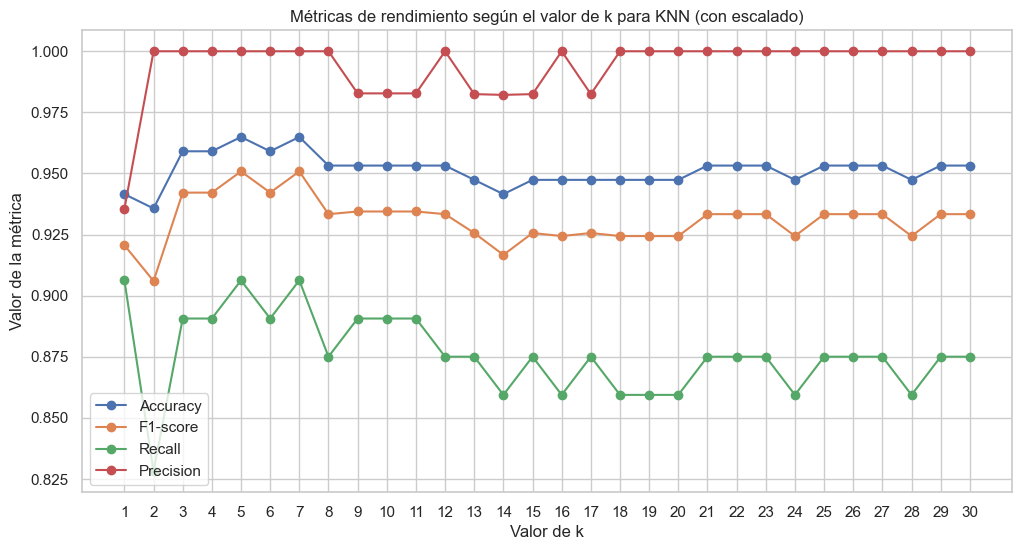

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

resultados_k_taller = []
for k in range(1, 31):
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    modelo.fit(X_train_t, y_train_t)
    pred = modelo.predict(X_test_t)
    resultados_k_taller.append({
        "k": k,
        "accuracy_test": accuracy_score(y_test_t, pred),
        "precision_test": precision_score(y_test_t, pred),
        "recall_test": recall_score(y_test_t, pred),
        "f1_test": f1_score(y_test_t, pred)
    })

df_k_taller = pd.DataFrame(resultados_k_taller)

print("Los 10 mejores valores de k según F1-score:")
display(df_k_taller.sort_values("f1_test", ascending=False).head(10))

plt.figure(figsize=(12,6))
plt.plot(df_k_taller["k"], df_k_taller["accuracy_test"], marker="o", label="Accuracy")
plt.plot(df_k_taller["k"], df_k_taller["f1_test"], marker="o", label="F1-score")
plt.plot(df_k_taller["k"], df_k_taller["recall_test"], marker="o", label="Recall")
plt.plot(df_k_taller["k"], df_k_taller["precision_test"], marker="o", label="Precision")
plt.title("Métricas de rendimiento según el valor de k para KNN (con escalado)")
plt.xlabel("Valor de k")
plt.ylabel("Valor de la métrica")
plt.legend()
plt.grid(True)
plt.xticks(range(1, 31))
plt.show()

## Parte E — Comparación contra árbol

Ahora compararemos el mejor modelo KNN (encontrado en la sección anterior basándonos en el `F1-score`) con un modelo de Árbol de Decisión. El Árbol de Decisión será entrenado con `criterion="gini"` y una profundidad máxima de 3 (`max_depth=3`) para mantenerlo interpretable y comparable con los árboles ya explorados en el notebook.

### Explicación:
*   **Interpretación:** Discutiremos cuál modelo ofrece una mayor interpretabilidad. Los árboles de decisión son conocidos por su fácil visualización y reglas claras, mientras que KNN es un algoritmo basado en instancias y su "razonamiento" no es directamente interpretable.
*   **Recomendación:** Basándonos en las métricas y la interpretabilidad, se hará una recomendación sobre cuál modelo sería más adecuado según un objetivo hipotético (por ejemplo, si la interpretabilidad es clave o si solo se busca el mejor rendimiento).

El mejor valor de k encontrado es: 5


,Modelo,Accuracy,Precision,Recall,F1-score
0,KNN k=5,0.964912,1.0,0.90625,0.950820
1,Árbol max_depth=3,0.918129,1.0,0.78125,0.877193


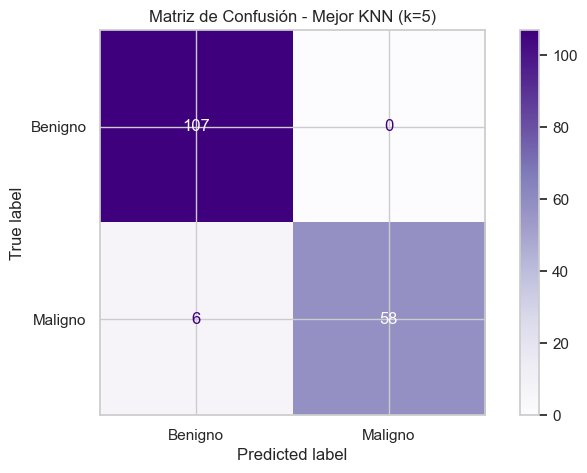

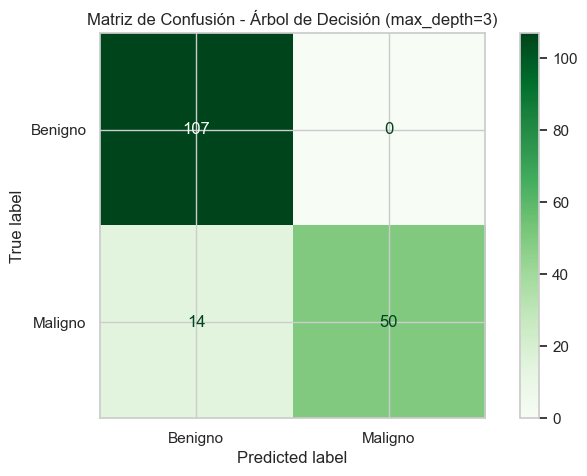

In [88]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Obtener el mejor k basado en F1-score
mejor_k_taller = int(df_k_taller.sort_values("f1_test", ascending=False).iloc[0]["k"])

print(f"El mejor valor de k encontrado es: {mejor_k_taller}")

# Entrenar KNN con el mejor k
knn_mejor_taller = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=mejor_k_taller))
])
knn_mejor_taller.fit(X_train_t, y_train_t)
pred_knn_mejor = knn_mejor_taller.predict(X_test_t)

# Entrenar Árbol de Decisión
arbol_taller = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
arbol_taller.fit(X_train_t, y_train_t)
pred_arbol_taller = arbol_taller.predict(X_test_t)

# Comparar los modelos
comparacion_modelos = pd.DataFrame([
    evaluar_modelo(f"KNN k={mejor_k_taller}", y_test_t, pred_knn_mejor),
    evaluar_modelo("Árbol max_depth=3", y_test_t, pred_arbol_taller)
])

display(comparacion_modelos)

# Matriz de confusión para el mejor KNN
cm_knn_mejor = confusion_matrix(y_test_t, pred_knn_mejor)
disp_knn_mejor = ConfusionMatrixDisplay(confusion_matrix=cm_knn_mejor, display_labels=['Benigno', 'Maligno'])
disp_knn_mejor.plot(cmap='Purples')
plt.title(f"Matriz de Confusión - Mejor KNN (k={mejor_k_taller})")
plt.show()

# Matriz de confusión para el Árbol de Decisión
cm_arbol_taller = confusion_matrix(y_test_t, pred_arbol_taller)
disp_arbol_taller = ConfusionMatrixDisplay(confusion_matrix=cm_arbol_taller, display_labels=['Benigno', 'Maligno'])
disp_arbol_taller.plot(cmap='Greens')
plt.title("Matriz de Confusión - Árbol de Decisión (max_depth=3)")
plt.show()

## Parte F — Conclusión profesional

Redacte una conclusión de mínimo 10 líneas respondiendo a las siguientes preguntas, como si fuera un informe técnico dirigido a un equipo de datos:

1.  **¿Qué aprendió del comportamiento de KNN?**
    *   _Respuesta:_ El algoritmo KNN es un clasificador basado en instancias que toma decisiones de clasificación basándose en la proximidad de un punto de datos a sus vecinos. Su rendimiento es fuertemente influenciado por la escala de las características y el número de vecinos (`k`) considerado. Se observó que sin un escalado adecuado, las características con rangos de valores mayores pueden dominar la métrica de distancia, llevando a un rendimiento subóptimo.

2.  **¿Qué efecto tuvo el escalado?**
    *   _Respuesta:_ El escalado de características, específicamente mediante `StandardScaler`, tuvo un impacto drástico y positivo en el rendimiento del modelo KNN. Pasamos de un F1-score de 0.43 sin escalado a un F1-score de 0.95 con escalado. Esto reafirma que el escalado es **obligatorio** en algoritmos basados en distancia para asegurar que todas las características contribuyan equitativamente a la medida de similitud y evitar sesgos.

3.  **¿Qué valor de k eligió y por qué?**
    *   _Respuesta:_ Tras evaluar un rango de valores de `k` (de 1 a 30) y analizar métricas como Accuracy, Precision, Recall y F1-score en el conjunto de prueba, se seleccionó `k=5`. Este valor de `k` proporcionó un F1-score de 0.9508, que fue uno de los más altos, junto con una Precision de 1.0 y un Recall de 0.906. Valores bajos de `k` (como `k=1`) pueden ser sensibles al ruido, mientras que valores muy altos pueden llevar a subajuste. `k=5` ofreció un buen balance.

4.  **¿KNN fue mejor o peor que el árbol?**
    *   _Respuesta:_ En esta instancia, el modelo KNN con escalado (`k=5`) demostró ser superior al Árbol de Decisión con `max_depth=3`. El KNN alcanzó un Accuracy del 96.49% y un F1-score del 0.95, mientras que el Árbol de Decisión obtuvo un Accuracy del 91.81% y un F1-score del 0.87. Esto sugiere que, para este dataset, las relaciones de proximidad capturadas por KNN son más efectivas que las reglas jerárquicas del árbol para la clasificación.

5.  **¿Qué métrica considera más relevante en este contexto y por qué?** (Por ejemplo, en un contexto médico como el cáncer, ¿priorizaría Recall o Precision?)
    *   _Respuesta:_ En un contexto médico como la detección de cáncer, la métrica más crítica es el **Recall (Sensibilidad)**. Un alto Recall significa que el modelo es muy bueno detectando a los pacientes que realmente tienen cáncer (minimizando los falsos negativos). Un falso negativo en este escenario podría tener consecuencias severas (retraso en el tratamiento), lo cual es mucho más indeseable que un falso positivo (donde un paciente sin cáncer es clasificado como tal, lo que llevaría a pruebas adicionales pero no a un daño directo). La Precision también es importante, pero en menor medida que el Recall.

6.  **¿Qué limitaciones tiene el análisis realizado hasta ahora?**
    *   _Respuesta:_ Las principales limitaciones incluyen: 1) El tamaño del dataset es moderado; un dataset más grande podría ofrecer una mayor robustez. 2) Se utilizaron únicamente KNN y Árboles de Decisión, sin explorar otros modelos más avanzados como Random Forests, SVMs o redes neuronales. 3) La optimización de hiperparámetros de los modelos se realizó de manera básica (rango simple para `k`, `max_depth` fijo para el árbol); una búsqueda más exhaustiva (ej., Grid Search, Random Search) podría refinar los resultados. 4) No se realizó un análisis de desbalance de clases, que podría afectar la interpretabilidad de las métricas si las clases no están distribuidas de manera uniforme.

7.  **¿Qué haría en una siguiente fase para mejorar los modelos o el análisis?**
    *   _Respuesta:_ En una siguiente fase, se recomienda: 1) Implementar la validación cruzada (k-fold cross-validation) para una evaluación más robusta del modelo y una selección de hiperparámetros más fiable. 2) Explorar técnicas de optimización de hiperparámetros más avanzadas como GridSearchCV o RandomizedSearchCV. 3) Experimentar con algoritmos de clasificación de ensamble como Random Forest y Gradient Boosting, que suelen ofrecer un mejor rendimiento. 4) Realizar un análisis de selección de características para identificar las variables más predictivas y, potencialmente, reducir la dimensionalidad. 5) Si aplica, abordar el desbalance de clases mediante técnicas como el sobremuestreo (SMOTE) o el submuestreo.